In [ ]:
# ============================================================
# NETFLIX CONTENT ANALYSIS — EDA & VISUALIZATIONS
# Author: Gopi
# Date: 15-6-26
# Purpose: Visual exploration of Netflix content catalog
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── CHART STYLING ────────────────────────────────────────────
# Set a professional dark theme for all charts
plt.style.use('dark_background')

# Custom Netflix-inspired color palette
NETFLIX_RED   = '#E50914'
NETFLIX_WHITE = '#FFFFFF'
NETFLIX_GRAY  = '#564d4d'
NETFLIX_DARK  = '#141414'

COLORS = [
    '#E50914','#FF6B6B','#FF8E53',
    '#FFC300','#DAF7A6','#4FC3F7',
    '#CE93D8','#80CBC4','#FFAB91','#B0BEC5'
]

# Set global font
plt.rcParams['font.family']  = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Load cleaned dataset
df = pd.read_csv('../data/cleaned/netflix_titles_cleaned.csv')

print(f" Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

✅ Dataset loaded: (8804, 20)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'month_added', 'month_name_added', 'duration_value', 'duration_unit', 'primary_country', 'content_age_when_added', 'content_freshness']


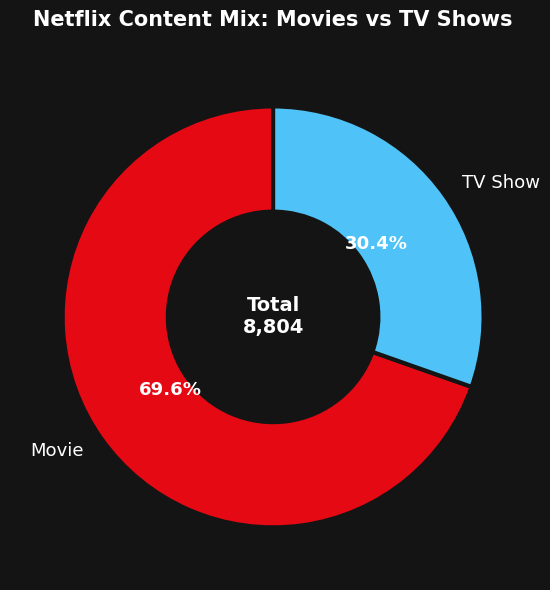

✅ Chart 1 saved


In [ ]:
# ── CHART 1: CONTENT TYPE DISTRIBUTION ───────────────────────

fig, ax = plt.subplots(figsize=(8, 6), facecolor=NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

# Count movies and TV shows
type_counts = df['type'].value_counts()

# Create donut chart
wedges, texts, autotexts = ax.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=[NETFLIX_RED, '#4FC3F7'],
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor=NETFLIX_DARK, linewidth=3),
    textprops={'color': NETFLIX_WHITE, 'fontsize': 13}
)

# Make percentages bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

# Add center text
ax.text(0, 0, f'Total\n{len(df):,}', 
        ha='center', va='center',
        fontsize=14, fontweight='bold',
        color=NETFLIX_WHITE)

ax.set_title('Netflix Content Mix: Movies vs TV Shows',
             color=NETFLIX_WHITE, pad=20, fontsize=15)

plt.tight_layout()
plt.savefig('../visuals/01_content_type_split.png',
            dpi=150, bbox_inches='tight',
            facecolor=NETFLIX_DARK)
plt.show()
print(" Chart 1 saved")

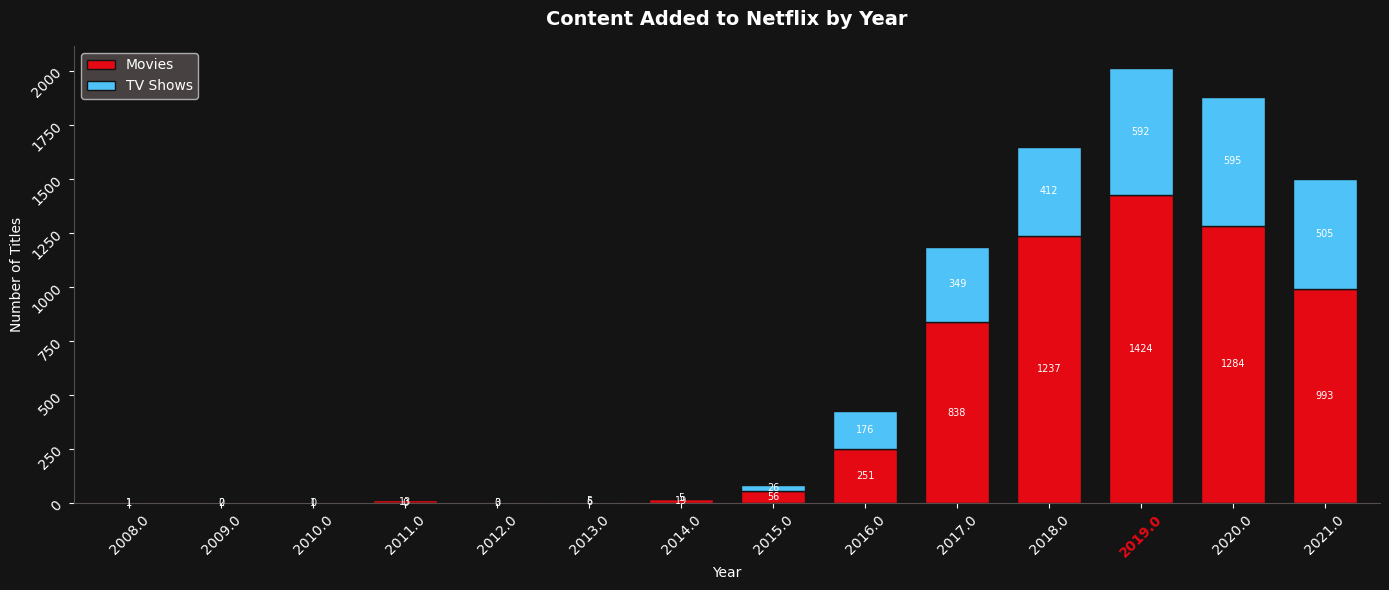

✅ Chart 2 saved | Peak year: 2019


In [ ]:
# ── CHART 2: CONTENT ADDED PER YEAR ──────────────────────────

fig, ax = plt.subplots(figsize=(14, 6), facecolor=NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

# Count titles per year
yearly = df[df['year_added'].notna()].groupby(
    ['year_added','type']
).size().unstack(fill_value=0)

# Plot stacked bar
yearly.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[NETFLIX_RED, '#4FC3F7'],
    edgecolor=NETFLIX_DARK,
    width=0.7
)

ax.set_title('Content Added to Netflix by Year',
             color=NETFLIX_WHITE, pad=15)
ax.set_xlabel('Year', color=NETFLIX_WHITE)
ax.set_ylabel('Number of Titles', color=NETFLIX_WHITE)
ax.tick_params(colors=NETFLIX_WHITE, rotation=45)
ax.legend(['Movies','TV Shows'],
          facecolor=NETFLIX_GRAY,
          labelcolor=NETFLIX_WHITE)

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, label_type='center',
                 color=NETFLIX_WHITE, fontsize=7)

# Highlight peak year
peak_year = yearly.sum(axis=1).idxmax()
peak_idx  = list(yearly.index).index(peak_year)
ax.get_xticklabels()[peak_idx].set_color(NETFLIX_RED)
ax.get_xticklabels()[peak_idx].set_fontweight('bold')

ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color(NETFLIX_GRAY)

plt.tight_layout()
plt.savefig('../visuals/02_content_per_year.png',
            dpi=150, bbox_inches='tight',
            facecolor=NETFLIX_DARK)
plt.show()
print(f" Chart 2 saved | Peak year: {int(peak_year)}")

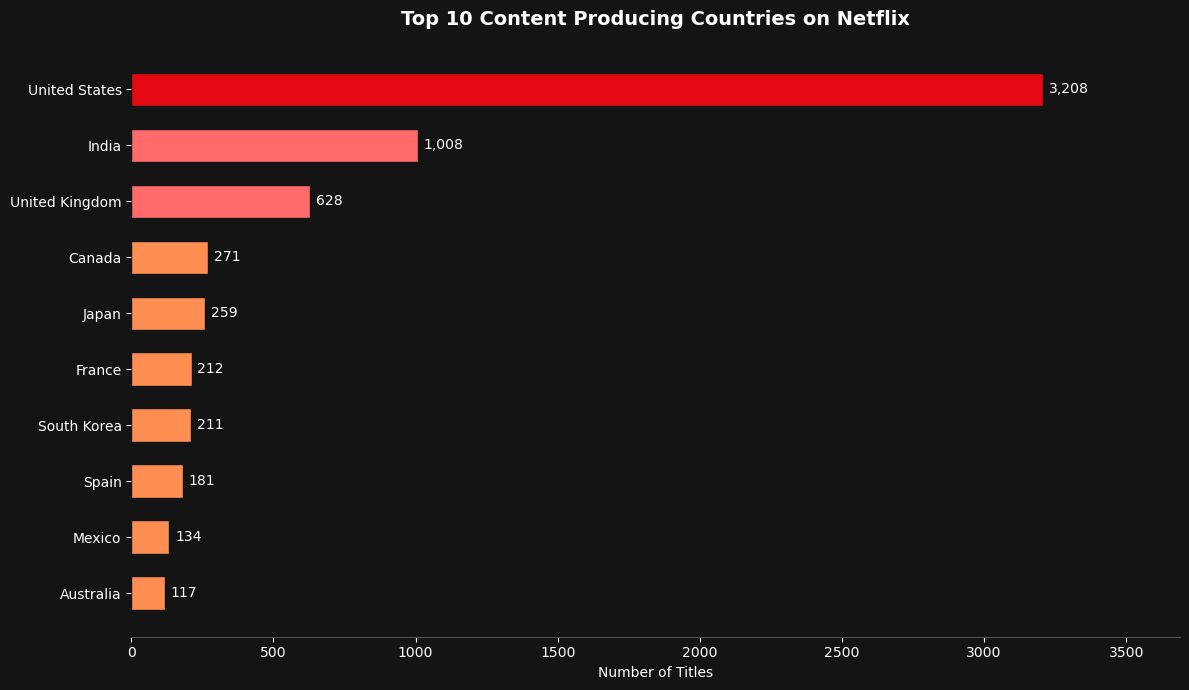

✅ Chart 3 saved


In [ ]:
# ── CHART 3: TOP 10 CONTENT PRODUCING COUNTRIES ──────────────

fig, ax = plt.subplots(figsize=(12, 7), facecolor=NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

# Get top 10 countries
top_countries = (
    df[df['primary_country'] != 'Unknown']
    ['primary_country']
    .value_counts()
    .head(10)
)

# Create color gradient — top country is Netflix red
bar_colors = [NETFLIX_RED] + ['#FF6B6B'] * 2 + ['#FF8E53'] * 7

bars = ax.barh(
    top_countries.index[::-1],
    top_countries.values[::-1],
    color=bar_colors[::-1],
    edgecolor=NETFLIX_DARK,
    height=0.6
)

# Add value labels
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color=NETFLIX_WHITE, fontsize=10)

ax.set_title('Top 10 Content Producing Countries on Netflix',
             color=NETFLIX_WHITE, pad=15)
ax.set_xlabel('Number of Titles', color=NETFLIX_WHITE)
ax.tick_params(colors=NETFLIX_WHITE)
ax.spines[['top','right','left']].set_visible(False)
ax.spines['bottom'].set_color(NETFLIX_GRAY)
ax.set_xlim(0, top_countries.max() * 1.15)

plt.tight_layout()
plt.savefig('../visuals/03_top_countries.png',
            dpi=150, bbox_inches='tight',
            facecolor=NETFLIX_DARK)
plt.show()
print(" Chart 3 saved")

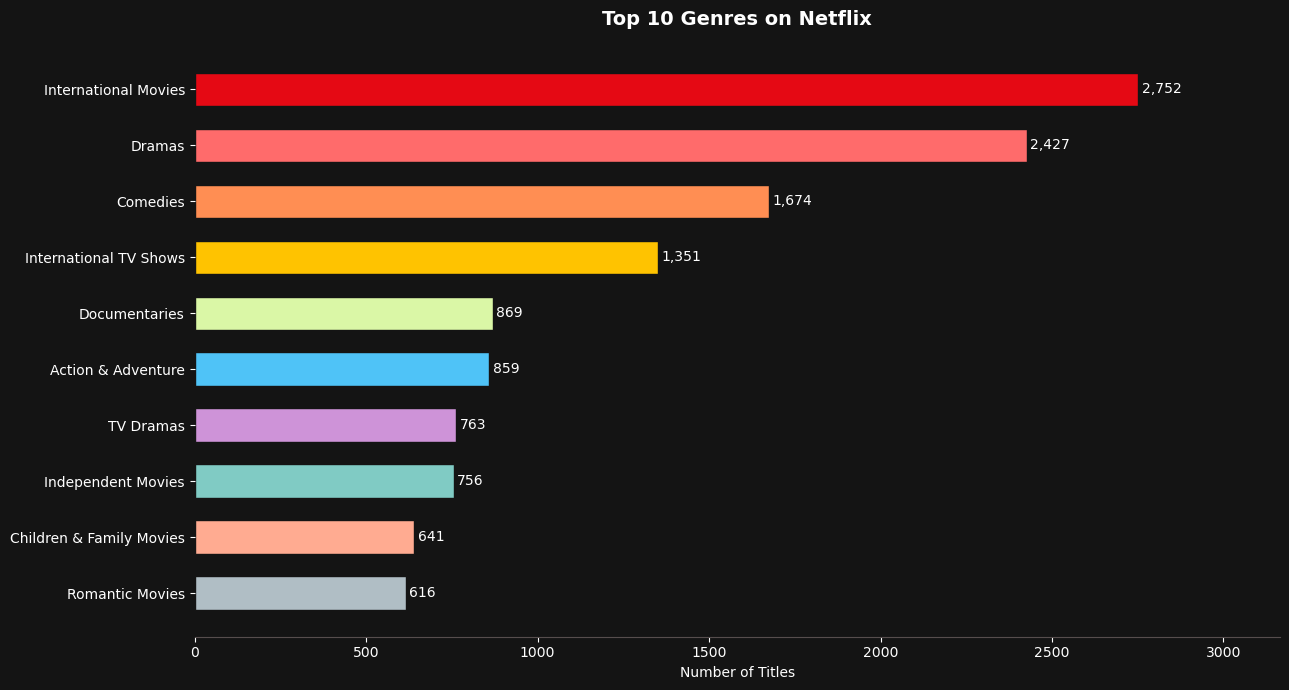

✅ Chart 4 saved


In [ ]:
# ── CHART 4: TOP 10 GENRES ────────────────────────────────────

# listed_in has multiple genres like "Dramas, International Movies"
# We need to split and count each genre individually
# This is called "exploding" a column

fig, ax = plt.subplots(figsize=(13, 7), facecolor=NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

# Split genres and explode into individual rows
genre_series = (
    df['listed_in']
    .str.split(',')          # split "Dramas, Action" into ["Dramas","Action"]
    .explode()               # make each genre its own row
    .str.strip()             # remove extra spaces
    .value_counts()          # count each genre
    .head(10)
)

bars = ax.barh(
    genre_series.index[::-1],
    genre_series.values[::-1],
    color=COLORS[:10][::-1],
    edgecolor=NETFLIX_DARK,
    height=0.6
)

for bar, val in zip(bars, genre_series.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color=NETFLIX_WHITE, fontsize=10)

ax.set_title('Top 10 Genres on Netflix',
             color=NETFLIX_WHITE, pad=15)
ax.set_xlabel('Number of Titles', color=NETFLIX_WHITE)
ax.tick_params(colors=NETFLIX_WHITE)
ax.spines[['top','right','left']].set_visible(False)
ax.spines['bottom'].set_color(NETFLIX_GRAY)
ax.set_xlim(0, genre_series.max() * 1.15)

plt.tight_layout()
plt.savefig('../visuals/04_top_genres.png',
            dpi=150, bbox_inches='tight',
            facecolor=NETFLIX_DARK)
plt.show()
print(" Chart 4 saved")

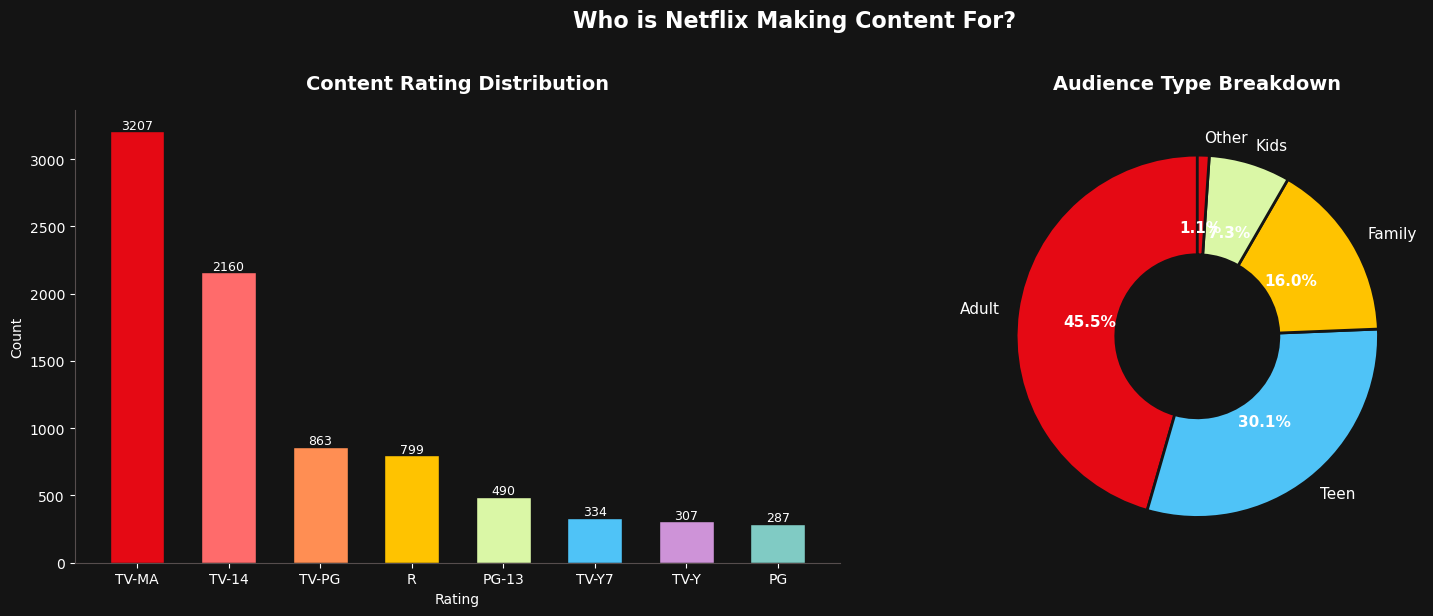

✅ Chart 5 saved


In [ ]:
# ── CHART 5: CONTENT RATING DISTRIBUTION ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=NETFLIX_DARK)

for ax in axes:
    ax.set_facecolor(NETFLIX_DARK)

# Left chart — Overall rating distribution
rating_counts = (
    df[df['rating'] != 'Unknown']['rating']
    .value_counts()
    .head(8)
)

axes[0].bar(
    rating_counts.index,
    rating_counts.values,
    color=COLORS[:len(rating_counts)],
    edgecolor=NETFLIX_DARK,
    width=0.6
)

for i, (idx, val) in enumerate(rating_counts.items()):
    axes[0].text(i, val + 20, str(val),
                 ha='center', color=NETFLIX_WHITE, fontsize=9)

axes[0].set_title('Content Rating Distribution',
                  color=NETFLIX_WHITE, pad=15)
axes[0].set_xlabel('Rating', color=NETFLIX_WHITE)
axes[0].set_ylabel('Count', color=NETFLIX_WHITE)
axes[0].tick_params(colors=NETFLIX_WHITE)
axes[0].spines[['top','right']].set_visible(False)
axes[0].spines[['left','bottom']].set_color(NETFLIX_GRAY)

# Right chart — Audience type breakdown
audience_map = {
    'TV-MA':'Adult', 'R':'Adult', 'NC-17':'Adult',
    'TV-14':'Teen',  'PG-13':'Teen',
    'TV-PG':'Family','PG':'Family',
    'TV-G':'Family', 'G':'Family',
    'TV-Y':'Kids',   'TV-Y7':'Kids'
}

df['audience_type'] = df['rating'].map(audience_map).fillna('Other')
audience_counts = df['audience_type'].value_counts()

wedges, texts, autotexts = axes[1].pie(
    audience_counts.values,
    labels=audience_counts.index,
    autopct='%1.1f%%',
    colors=[NETFLIX_RED,'#4FC3F7','#FFC300','#DAF7A6'],
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=NETFLIX_DARK, linewidth=2),
    textprops={'color':NETFLIX_WHITE,'fontsize':11}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')

axes[1].set_title('Audience Type Breakdown',
                  color=NETFLIX_WHITE, pad=15)

plt.suptitle('Who is Netflix Making Content For?',
             color=NETFLIX_WHITE, fontsize=16,
             fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../visuals/05_rating_distribution.png',
            dpi=150, bbox_inches='tight',
            facecolor=NETFLIX_DARK)
plt.show()
print(" Chart 5 saved")

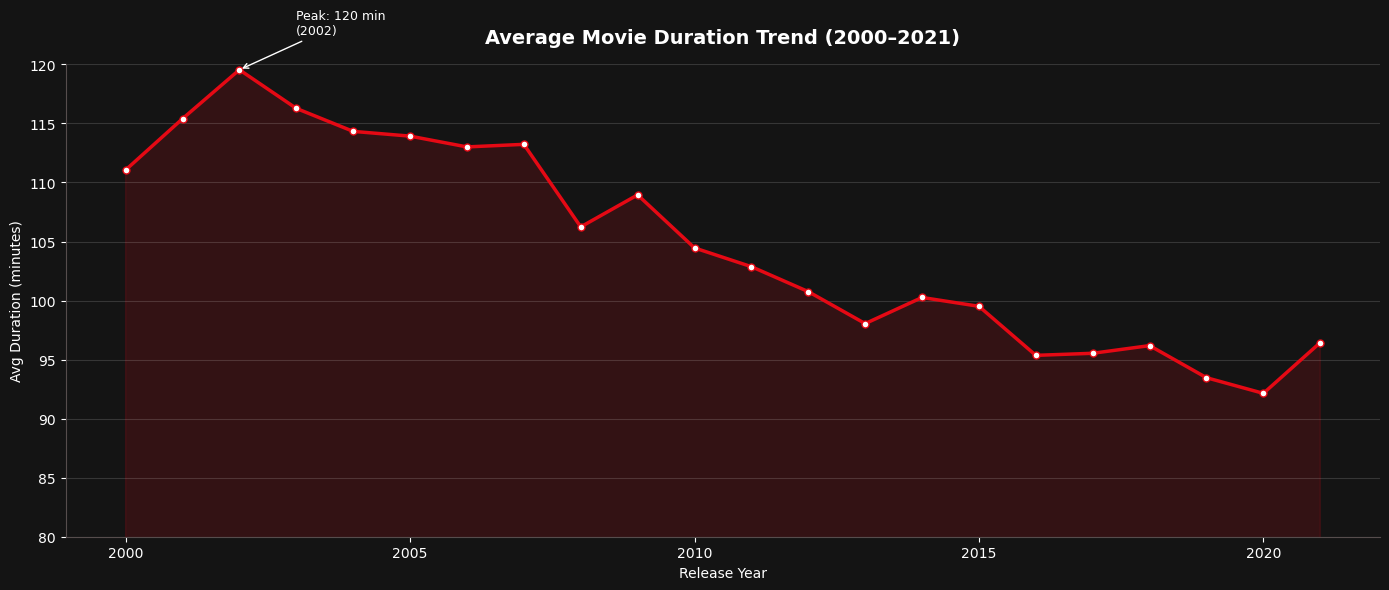

✅ Chart 6 saved


In [ ]:
# ── CHART 6: AVERAGE MOVIE DURATION TREND ────────────────────

fig, ax = plt.subplots(figsize=(14, 6), facecolor=NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

# Filter movies only, year 2000 onwards
movies_df = df[
    (df['type'] == 'Movie') &
    (df['duration_unit'] == 'min') &
    (df['release_year'] >= 2000) &
    (df['duration_value'].notna())
]

# Average duration per year
duration_trend = (
    movies_df.groupby('release_year')['duration_value']
    .agg(['mean','count'])
    .reset_index()
)
duration_trend.columns = ['year','avg_duration','count']

# Line chart
ax.plot(
    duration_trend['year'],
    duration_trend['avg_duration'],
    color=NETFLIX_RED,
    linewidth=2.5,
    marker='o',
    markersize=5,
    markerfacecolor=NETFLIX_WHITE
)

# Shade area under line
ax.fill_between(
    duration_trend['year'],
    duration_trend['avg_duration'],
    alpha=0.15,
    color=NETFLIX_RED
)

# Add trend annotation
max_dur = duration_trend.loc[duration_trend['avg_duration'].idxmax()]
ax.annotate(
    f"Peak: {max_dur['avg_duration']:.0f} min\n({int(max_dur['year'])})",
    xy=(max_dur['year'], max_dur['avg_duration']),
    xytext=(max_dur['year']+1, max_dur['avg_duration']+3),
    color=NETFLIX_WHITE,
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color=NETFLIX_WHITE)
)

ax.set_title('Average Movie Duration Trend (2000–2021)',
             color=NETFLIX_WHITE, pad=15)
ax.set_xlabel('Release Year', color=NETFLIX_WHITE)
ax.set_ylabel('Avg Duration (minutes)', color=NETFLIX_WHITE)
ax.tick_params(colors=NETFLIX_WHITE)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color(NETFLIX_GRAY)
ax.set_ylim(80, 120)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.grid(axis='y', alpha=0.15, color=NETFLIX_WHITE)

plt.tight_layout()
plt.savefig('../visuals/06_movie_duration_trend.png',
            dpi=150, bbox_inches='tight',
            facecolor=NETFLIX_DARK)
plt.show()
print("Chart 6 saved")

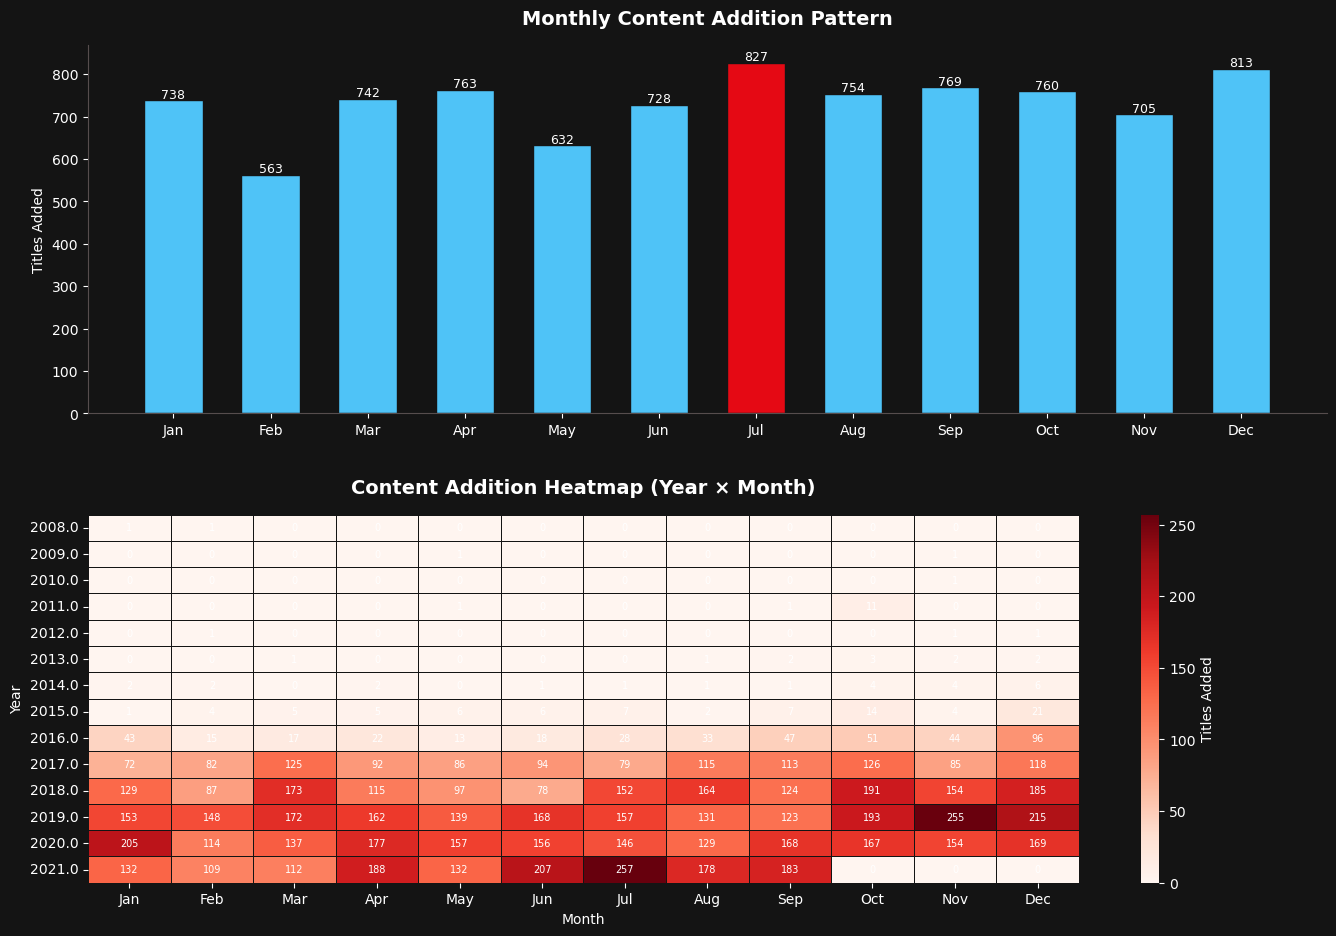

✅ Chart 7 saved


In [ ]:
# ── CHART 7: MONTHLY CONTENT ADDITION PATTERN ────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10), facecolor=NETFLIX_DARK)

for ax in axes:
    ax.set_facecolor(NETFLIX_DARK)

# Monthly counts
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = (
    df[df['month_name_added'].notna() & 
       (df['month_name_added'] != 'NaN')]
    .groupby('month_name_added')
    .size()
    .reindex(month_order, fill_value=0)
)

# Top chart — Bar chart
bars = axes[0].bar(
    range(len(monthly)),
    monthly.values,
    color=[NETFLIX_RED if v == monthly.max() 
           else '#4FC3F7' for v in monthly.values],
    edgecolor=NETFLIX_DARK,
    width=0.6
)

axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(
    [m[:3] for m in month_order],
    color=NETFLIX_WHITE
)
axes[0].set_title('Monthly Content Addition Pattern',
                  color=NETFLIX_WHITE, pad=15)
axes[0].set_ylabel('Titles Added', color=NETFLIX_WHITE)
axes[0].tick_params(colors=NETFLIX_WHITE)
axes[0].spines[['top','right']].set_visible(False)
axes[0].spines[['left','bottom']].set_color(NETFLIX_GRAY)

for bar, val in zip(bars, monthly.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(val), ha='center',
        color=NETFLIX_WHITE, fontsize=9
    )

# Bottom chart — Year x Month heatmap
pivot = (
    df[df['year_added'].notna() & df['month_added'].notna()]
    .groupby(['year_added','month_added'])
    .size()
    .unstack(fill_value=0)
)

sns.heatmap(
    pivot,
    ax=axes[1],
    cmap='Reds',
    linewidths=0.5,
    linecolor=NETFLIX_DARK,
    annot=True,
    fmt='d',
    annot_kws={'size':7, 'color':'white'},
    cbar_kws={'label':'Titles Added'}
)

axes[1].set_title('Content Addition Heatmap (Year × Month)',
                  color=NETFLIX_WHITE, pad=15)
axes[1].set_xlabel('Month', color=NETFLIX_WHITE)
axes[1].set_ylabel('Year', color=NETFLIX_WHITE)
axes[1].tick_params(colors=NETFLIX_WHITE)
axes[1].set_xticklabels(
    [m[:3] for m in month_order],
    color=NETFLIX_WHITE, rotation=0
)

plt.tight_layout(pad=3)
plt.savefig('../visuals/07_monthly_pattern.png',
            dpi=150, bbox_inches='tight',
            facecolor=NETFLIX_DARK)
plt.show()
print(" Chart 7 saved")

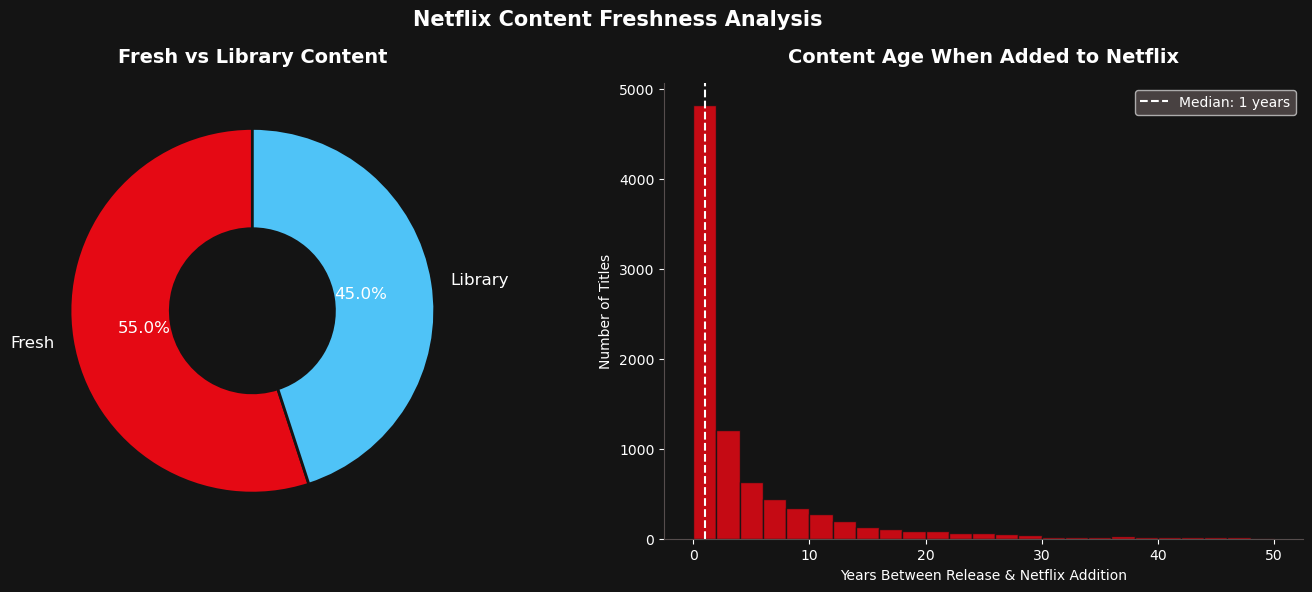

✅ Chart 8 saved


In [ ]:
# ── CHART 8: FRESH VS LIBRARY CONTENT ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=NETFLIX_DARK)

for ax in axes:
    ax.set_facecolor(NETFLIX_DARK)

# Left — Overall freshness split
fresh_counts = (
    df[df['content_freshness'] != 'Unknown']
    ['content_freshness']
    .value_counts()
)

axes[0].pie(
    fresh_counts.values,
    labels=fresh_counts.index,
    autopct='%1.1f%%',
    colors=[NETFLIX_RED, '#4FC3F7'],
    startangle=90,
    wedgeprops=dict(width=0.55,
                    edgecolor=NETFLIX_DARK,
                    linewidth=2),
    textprops={'color':NETFLIX_WHITE,'fontsize':12}
)
axes[0].set_title('Fresh vs Library Content',
                  color=NETFLIX_WHITE, pad=15)

# Right — Content age distribution histogram
age_data = df[
    (df['content_age_when_added'].notna()) &
    (df['content_age_when_added'] >= 0) &
    (df['content_age_when_added'] <= 50)
]['content_age_when_added']

axes[1].hist(
    age_data,
    bins=25,
    color=NETFLIX_RED,
    edgecolor=NETFLIX_DARK,
    alpha=0.85
)

axes[1].axvline(
    age_data.median(),
    color=NETFLIX_WHITE,
    linestyle='--',
    linewidth=1.5,
    label=f'Median: {age_data.median():.0f} years'
)

axes[1].set_title('Content Age When Added to Netflix',
                  color=NETFLIX_WHITE, pad=15)
axes[1].set_xlabel('Years Between Release & Netflix Addition',
                   color=NETFLIX_WHITE)
axes[1].set_ylabel('Number of Titles', color=NETFLIX_WHITE)
axes[1].tick_params(colors=NETFLIX_WHITE)
axes[1].legend(facecolor=NETFLIX_GRAY,
               labelcolor=NETFLIX_WHITE)
axes[1].spines[['top','right']].set_visible(False)
axes[1].spines[['left','bottom']].set_color(NETFLIX_GRAY)

plt.suptitle('Netflix Content Freshness Analysis',
             color=NETFLIX_WHITE, fontsize=15,
             fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/08_content_freshness.png',
            dpi=150, bbox_inches='tight',
            facecolor=NETFLIX_DARK)
plt.show()
print(" Chart 8 saved")

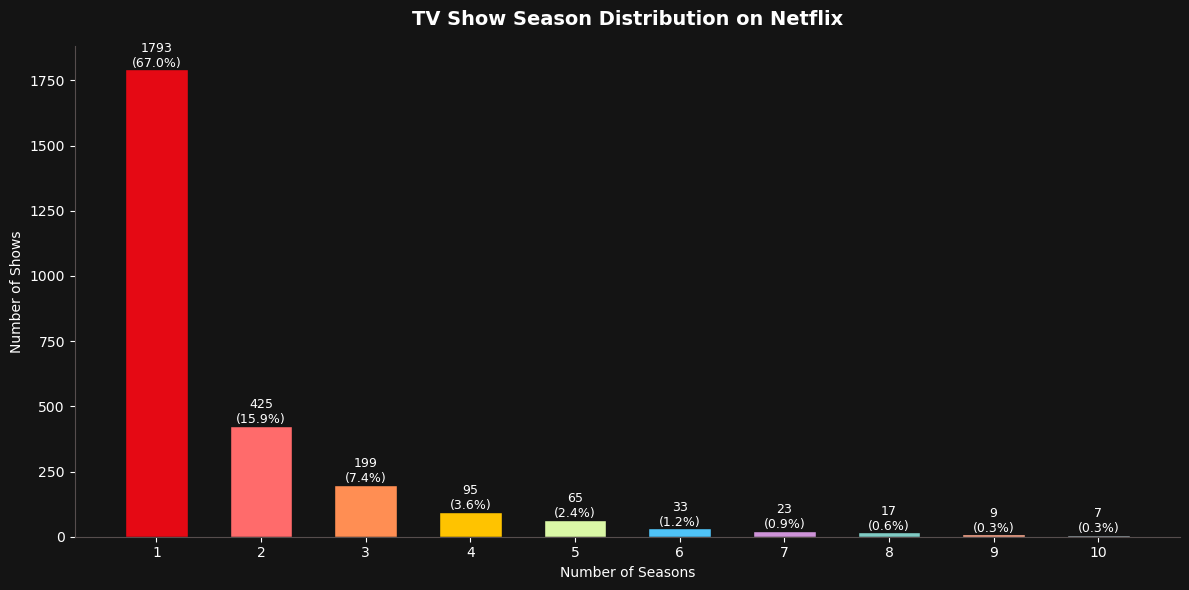

✅ Chart 9 saved


In [ ]:
# ── CHART 9: TV SHOW SEASON DISTRIBUTION ─────────────────────

fig, ax = plt.subplots(figsize=(12, 6), facecolor=NETFLIX_DARK)
ax.set_facecolor(NETFLIX_DARK)

tv_seasons = (
    df[df['type'] == 'TV Show']['duration_value']
    .value_counts()
    .sort_index()
    .head(10)
)

bars = ax.bar(
    tv_seasons.index.astype(int).astype(str),
    tv_seasons.values,
    color=[NETFLIX_RED if i == 0 
           else COLORS[i % len(COLORS)] 
           for i in range(len(tv_seasons))],
    edgecolor=NETFLIX_DARK,
    width=0.6
)

for bar, val in zip(bars, tv_seasons.values):
    pct = val / len(df[df['type']=='TV Show']) * 100
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{val}\n({pct:.1f}%)',
        ha='center', color=NETFLIX_WHITE, fontsize=9
    )

ax.set_title('TV Show Season Distribution on Netflix',
             color=NETFLIX_WHITE, pad=15)
ax.set_xlabel('Number of Seasons', color=NETFLIX_WHITE)
ax.set_ylabel('Number of Shows', color=NETFLIX_WHITE)
ax.tick_params(colors=NETFLIX_WHITE)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color(NETFLIX_GRAY)

plt.tight_layout()
plt.savefig('../visuals/09_tv_seasons.png',
            dpi=150, bbox_inches='tight',
            facecolor=NETFLIX_DARK)
plt.show()
print(" Chart 9 saved")

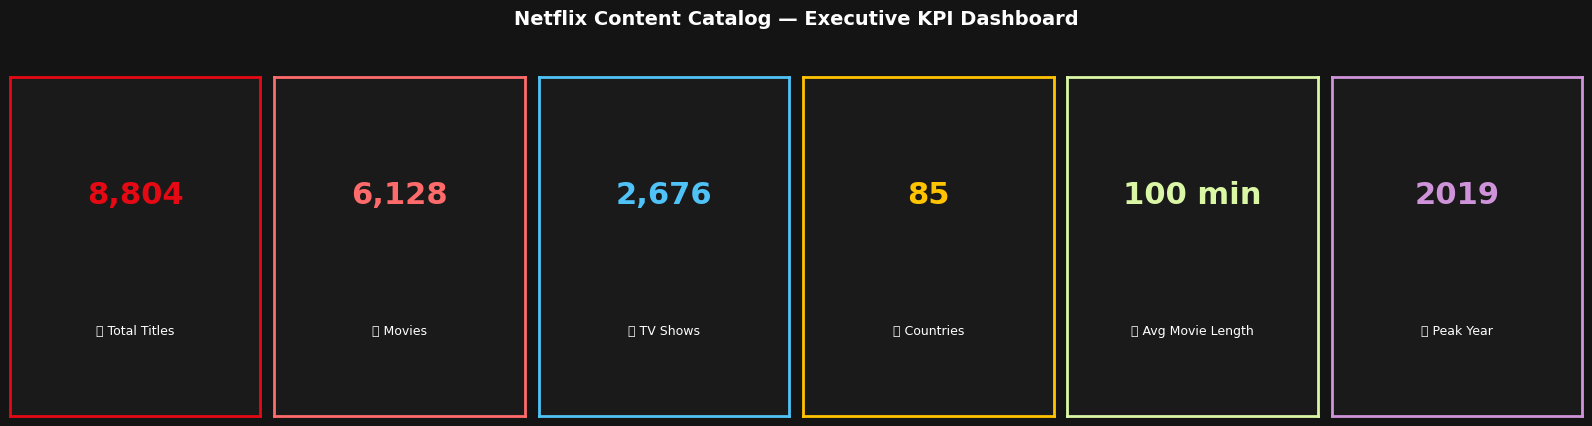

✅ Chart 10 — KPI Dashboard saved


In [ ]:
# ── CHART 10: KPI SUMMARY CARD ───────────────────────────────

fig = plt.figure(figsize=(16, 4), facecolor=NETFLIX_DARK)

# Calculate KPIs
total_titles    = len(df)
total_movies    = len(df[df['type']=='Movie'])
total_tvshows   = len(df[df['type']=='TV Show'])
total_countries = df[df['primary_country']!='Unknown']['primary_country'].nunique()
avg_movie_dur   = df[df['type']=='Movie']['duration_value'].mean()
peak_year       = int(df['year_added'].value_counts().idxmax())

kpis = [
    ('🎬 Total Titles',    f'{total_titles:,}',       NETFLIX_RED),
    ('🎥 Movies',          f'{total_movies:,}',        '#FF6B6B'),
    ('📺 TV Shows',        f'{total_tvshows:,}',       '#4FC3F7'),
    ('🌍 Countries',       f'{total_countries}',        '#FFC300'),
    ('⏱ Avg Movie Length', f'{avg_movie_dur:.0f} min', '#DAF7A6'),
    ('📅 Peak Year',       f'{peak_year}',              '#CE93D8'),
]

for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(1, 6, i+1)
    ax.set_facecolor('#1a1a1a')

    ax.text(0.5, 0.65, value,
            ha='center', va='center',
            fontsize=22, fontweight='bold',
            color=color,
            transform=ax.transAxes)

    ax.text(0.5, 0.25, label,
            ha='center', va='center',
            fontsize=9, color=NETFLIX_WHITE,
            transform=ax.transAxes,
            wrap=True)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

plt.suptitle('Netflix Content Catalog — Executive KPI Dashboard',
             color=NETFLIX_WHITE, fontsize=14,
             fontweight='bold', y=1.05)

plt.tight_layout(pad=1)
plt.savefig('../visuals/10_kpi_summary.png',
            dpi=150, bbox_inches='tight',
            facecolor=NETFLIX_DARK)
plt.show()
print(" Chart 10 — KPI Dashboard saved")

In [ ]:
# ── FINAL VERIFICATION ────────────────────────────────────────
import os

visuals_folder = '../visuals/'
saved_charts   = os.listdir(visuals_folder)

print("CHARTS SAVED IN /visuals/ FOLDER:")
print("=" * 45)
for chart in sorted(saved_charts):
    size = os.path.getsize(f'{visuals_folder}{chart}')
    print(f"   {chart} ({size/1024:.1f} KB)")

print(f"\nTotal charts: {len(saved_charts)}")
print("\n All visualizations complete!")

CHARTS SAVED IN /visuals/ FOLDER:
  ✅ 01_content_type_split.png (48.5 KB)
  ✅ 02_content_per_year.png (74.7 KB)
  ✅ 03_top_countries.png (59.0 KB)
  ✅ 04_top_genres.png (70.4 KB)
  ✅ 05_rating_distribution.png (100.1 KB)
  ✅ 06_movie_duration_trend.png (76.7 KB)
  ✅ 07_monthly_pattern.png (152.6 KB)
  ✅ 08_content_freshness.png (89.7 KB)
  ✅ 09_tv_seasons.png (62.5 KB)
  ✅ 10_kpi_summary.png (53.3 KB)

Total charts: 10

 All visualizations complete!
